# Edinburgh Airbnb — EDA Part 3: Temporal, Host/Supply, and Review/Demand Analysis

This notebook examines booking patterns, host behaviour, and review-related demand metrics across the Edinburgh Airbnb market.

Daily price data is unavailable in the snapshot's `calendar.csv` file, so temporal analysis focuses on availability and occupancy rather than price trends.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/processed/edinburgh/listings_master.csv", low_memory=False)

# Load the DuckDB star schema for temporal analysis
con = duckdb.connect("../data/processed/edinburgh/edinburgh_airbnb.duckdb", read_only=True)

print(f"{len(df):,} listings loaded")

4,925 listings loaded


## Booking patterns over the calendar year

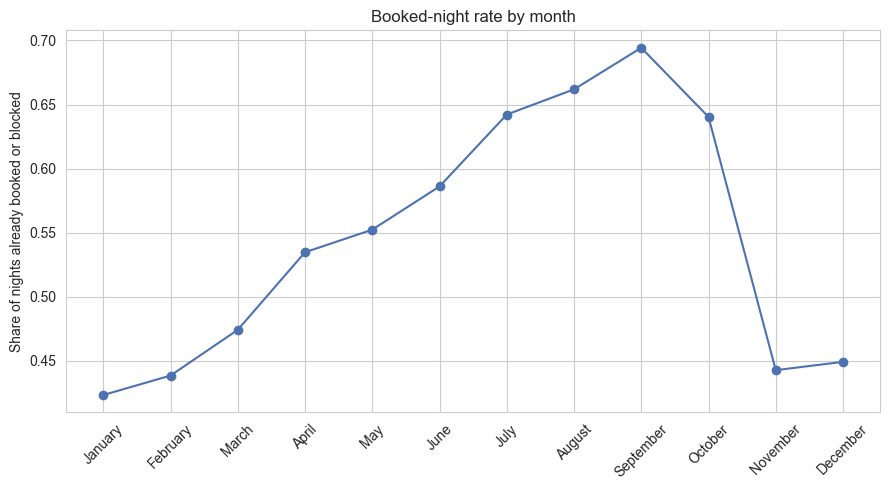

In [2]:
monthly_booking = con.sql("""
    SELECT d.month, d.month_name,
           AVG(CASE WHEN c.available = false THEN 1 ELSE 0 END) AS booked_rate
    FROM fact_calendar_daily c
    JOIN dim_date d ON c.date = d.date
    GROUP BY d.month, d.month_name
    ORDER BY d.month
""").df()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_booking["month_name"], monthly_booking["booked_rate"], marker="o", color="#4C72B0")
ax.set_title("Booked-night rate by month")
ax.set_ylabel("Share of nights already booked or blocked")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig10_seasonal_booking_rate.png", dpi=150)
plt.show() 

**Figure 10: Booking rate by month.** The share of nights already booked or blocked increases steadily from January (42.3%) through the summer months, peaking at 69.4% in September. Because the calendar covers the year ahead of the September 2025 snapshot date, this pattern reflects how far in advance future dates have already been reserved rather than historical demand.

August (66.2%) and September (69.4%) stand out as the most heavily booked periods, which is consistent with Edinburgh's peak tourism season and major events such as the Edinburgh Festival. Booking rates then fall sharply for November (44.3%) and December (44.9%), suggesting that guests were much less likely to have committed to those dates at the time of the snapshot, either because demand is lower or because bookings for those months are typically made closer to the stay date.

In [3]:
# Validate availability of minimum_nights in calendar.csv
min_nights_check = con.sql("""
    SELECT COUNT(*) AS total_rows, COUNT(minimum_nights) AS non_null_rows
    FROM read_csv_auto('../data/raw/edinburgh/calendar.csv')
""").df()
print(min_nights_check)

   total_rows  non_null_rows
0     1801640        1801640


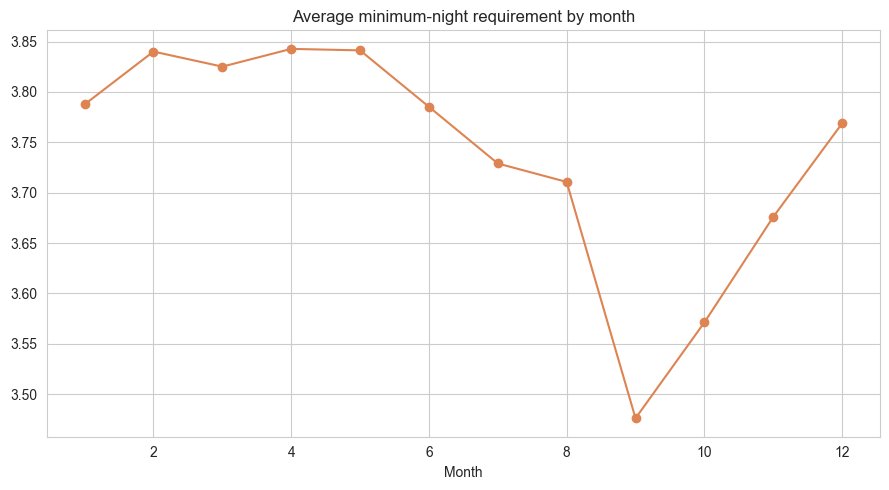

In [4]:
monthly_min_nights = con.sql("""
    SELECT EXTRACT(month FROM date) AS month, AVG(minimum_nights) AS avg_min_nights
    FROM read_csv_auto('../data/raw/edinburgh/calendar.csv')
    WHERE minimum_nights IS NOT NULL
    GROUP BY month
    ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_min_nights["month"], monthly_min_nights["avg_min_nights"], marker="o", color="#DD8452")
ax.set_title("Average minimum-night requirement by month")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_minimum_nights_seasonality.png", dpi=150)
plt.show() 

**Minimum nights across the year.** The average minimum-night requirement remains remarkably stable throughout the year, ranging from approximately 3.48 to 3.84 nights. There is a small dip in September, but the overall variation is less than half a night across all months, suggesting that hosts do not substantially adjust their minimum-stay requirements throughout the calendar year. Unlike booking rates, which show clear seasonal patterns, minimum-night policies appear to be relatively consistent regardless of the booking period.

## Review volume over time 

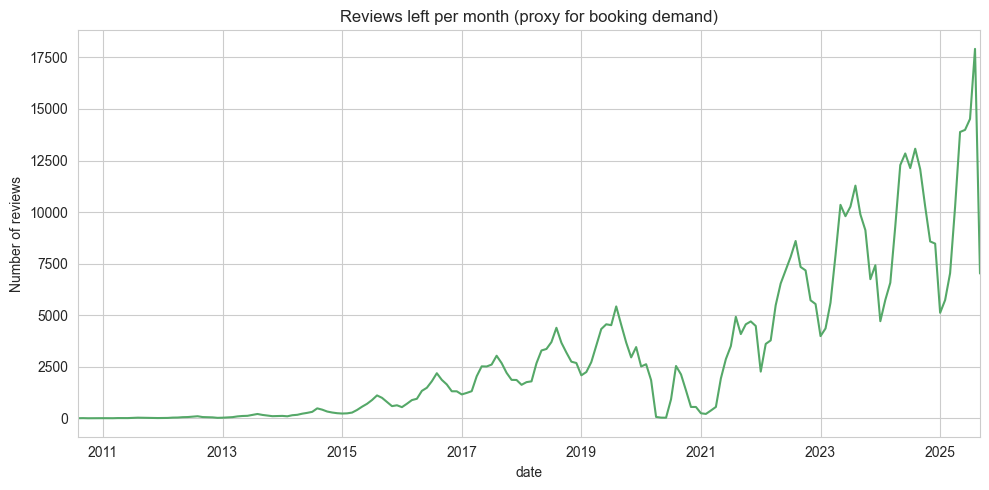

In [5]:
reviews = pd.read_csv(
    "../data/raw/edinburgh/reviews.csv", usecols=["listing_id", "date"], parse_dates=["date"]
)
monthly_reviews = reviews.set_index("date").resample("MS").size()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_reviews.plot(ax=ax, color="#55A868")
ax.set_title("Reviews left per month (proxy for booking demand)")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig11_review_volume_over_time.png", dpi=150)
plt.show()

**Figure 11: Review volume over time.** Review activity shows a strong long-term upward trend, increasing from very low levels in the early 2010s to more than 15,000 reviews per month by 2025. The series also exhibits clear seasonality, with recurring annual peaks and troughs, suggesting that guest demand varies substantially throughout the year.

A sharp decline is visible in the final month of the series, but this should not be interpreted as a sudden collapse in demand. The dataset snapshot was taken on 21 September 2025, meaning the final month is incomplete and many guests from recent stays would not yet have had time to leave reviews. As a result, the apparent drop at the end is most likely a data-collection artifact rather than a genuine change in booking activity.

## Host tenure vs price

/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


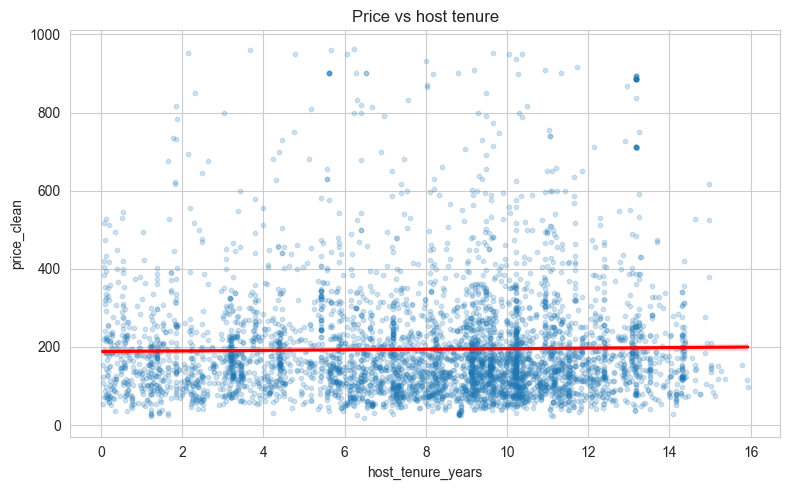

Correlation: 0.068


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df[df["price_clean"] < 1000],
    x="host_tenure_years", y="price_clean",
    scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red"}, ax=ax,
)
ax.set_title("Price vs host tenure")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig12_price_vs_host_tenure.png", dpi=150)
plt.show()

print(f"Correlation: {df[['host_tenure_years', 'price_clean']].corr().iloc[0, 1]:.3f}")

**Figure 12: Host tenure vs price.** The relationship between host tenure and listing price is extremely weak, with a correlation of just 0.068. While the fitted trend line slopes slightly upward, the scatter plot shows substantial variation in prices at every tenure level, indicating that host experience alone explains very little of the variation in nightly rates.

There is little evidence that newer hosts systematically underprice their listings to attract initial reviews, nor that long-established hosts are consistently able to charge a large premium. Other factors such as location, property type, room type, and listing quality appear to have a much stronger influence on price than host tenure.

## Host & supply-side analysis

In [7]:
host_counts = df["host_id"].value_counts().rename("n_listings")
df = df.merge(host_counts, left_on="host_id", right_index=True)


def segment_host(n):
    if n == 1:
        return "Single listing"
    elif n <= 5:
        return "Small operator (2-5)"
    return "Professional operator (6+)"


# Segment hosts by number of listings owned. 
df["host_segment"] = df["n_listings"].apply(segment_host)

df.groupby("host_segment").agg(
    n_listings=("id", "count"),
    median_price=("price_clean", "median"),
    avg_occupancy=("occupancy_rate", "mean"),
).round(2)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,n_listings,median_price,avg_occupancy
host_segment,,,
Professional operator (6+),1104,199.5,0.45
Single listing,2410,146.0,0.60
Small operator (2-5),1411,152.0,0.53


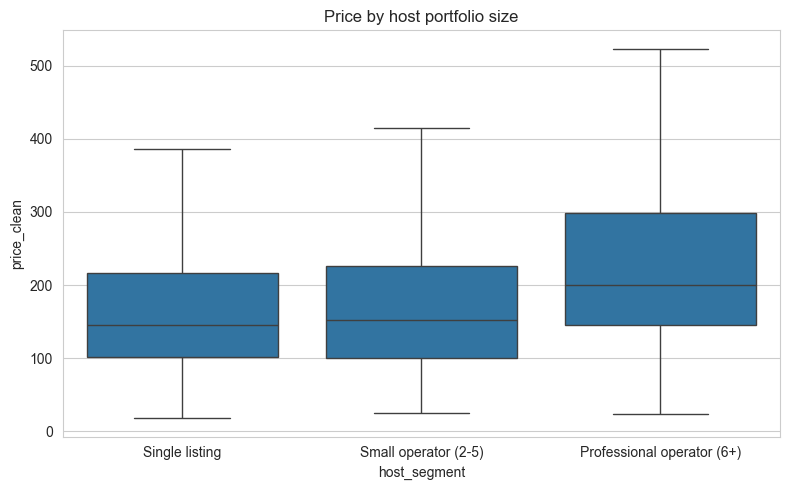

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ["Single listing", "Small operator (2-5)", "Professional operator (6+)"]
sns.boxplot(data=df, x="host_segment", y="price_clean", order=order, showfliers=False, ax=ax)
ax.set_title("Price by host portfolio size")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig13_price_by_host_segment.png", dpi=150)
plt.show() 

**Figure 13: Price by host segment.** Professional operators (hosts with six or more listings) have noticeably higher listing prices than both single-listing hosts and small operators. The median price for professional operators is around £200 per night, compared with roughly £145–£150 for the other two groups, and the upper end of their price distribution is substantially higher as well.

This suggests that larger operators tend to manage more expensive properties or are better positioned to charge premium rates. There is little difference between single-listing hosts and small operators, while the gap becomes much more pronounced for hosts managing larger portfolios.

In [9]:
df.groupby("host_is_superhost").agg(
    median_price=("price_clean", "median"),
    avg_review_score=("review_scores_rating", "mean"),
    avg_occupancy=("occupancy_rate", "mean"),
    n_listings=("id", "count"),
).round(2)

,median_price,avg_review_score,avg_occupancy,n_listings
host_is_superhost,,,,
f,164.0,4.69,0.51,2585
t,155.0,4.88,0.58,2196


**Superhost comparison.** Superhosts have substantially higher review scores and occupancy rates than non-superhosts. The average review score for superhosts is 4.88 compared with 4.69 for other hosts, while average occupancy is 58% versus 51%, suggesting that superhosts attract more bookings and deliver a more consistently positive guest experience.

Median prices are very similar (£155 for superhosts versus £164 for non-superhosts), indicating that the superhost premium is not primarily driven by higher prices. This aligns with the earlier room-type analysis: while some room categories showed higher prices for superhosts, the overall market-level difference is small once all property types are combined. Given that 79.4% of hosts operate a single listing while the top 10% of hosts control 38.0% of all listings, the superhost designation appears to be more strongly associated with guest satisfaction and occupancy than with charging higher prices.

## Review & demand-side analysis

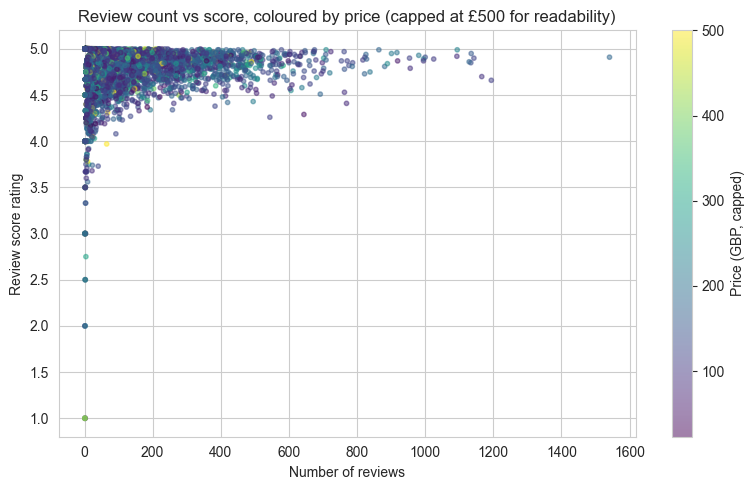

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    df["number_of_reviews"], df["review_scores_rating"],
    c=df["price_clean"].clip(upper=500), cmap="viridis", alpha=0.5, s=10,
)
ax.set_xlabel("Number of reviews")
ax.set_ylabel("Review score rating")
ax.set_title("Review count vs score, coloured by price (capped at £500 for readability)")
fig.colorbar(sc, label="Price (GBP, capped)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig14_reviews_score_price.png", dpi=150)
plt.show() 

In [11]:
high_volume_low_score = df[
    (df["number_of_reviews"] > df["number_of_reviews"].quantile(0.75))
    & (df["review_scores_rating"] < 4.5)
]
print(f"{len(high_volume_low_score)} listings have high review counts but below-average scores")
high_volume_low_score[
    ["name", "room_type", "price_clean", "number_of_reviews", "review_scores_rating"]
].sort_values("number_of_reviews", ascending=False).head(10) 

28 listings have high review counts but below-average scores


,name,room_type,price_clean,number_of_reviews,review_scores_rating
51,"VINTAGE apt,pvt GARDEN,wifiNEW TOWN",Entire home/apt,80.0,769,4.41
1406,St Christopher's Inn Bed in 18 Bed Dorm,Hotel room,48.0,644,4.29
239,Very Central Fresh Spacious Rooms,Private room,81.0,551,4.49
3523,Cosy room w/ shared spaces: Adults Only 18+,Entire home/apt,114.0,544,4.26
352,The Rose Residence,Entire home/apt,223.0,495,4.43
702,Central main door flat over 2floors,Entire home/apt,180.0,420,4.42
1287,Entire flat to rent. Central. 15 min Princess St.,Entire home/apt,75.0,414,4.49
1383,Second floor Haymarket apt with private parking,Entire home/apt,188.0,405,4.48
315,Lovely central Edinburgh apartment,Entire home/apt,125.0,383,4.38
1068,"Hawkhill - 2 Bed, Modern Apartment with Parking",Entire home/apt,152.0,307,4.46


**Figure 14 and the high-volume/low-score table.** The scatter plot reinforces a pattern seen earlier in the project: review scores are heavily concentrated near the top of the scale, even for listings with hundreds of reviews. Most highly reviewed listings maintain ratings above 4.5, suggesting that sustained popularity and guest satisfaction often go together.

The small group of listings with very high review counts but below-average ratings tells a more nuanced story. Many of these properties are relatively inexpensive, with prices commonly between £48 and £188 per night, and include several private rooms, hotel-style accommodation, and budget entire-home listings. Rather than indicating poor-quality properties, these listings appear to occupy a "value-for-money" segment of the market: they attract large numbers of bookings because of their location or affordability, despite receiving slightly weaker reviews than their competitors.

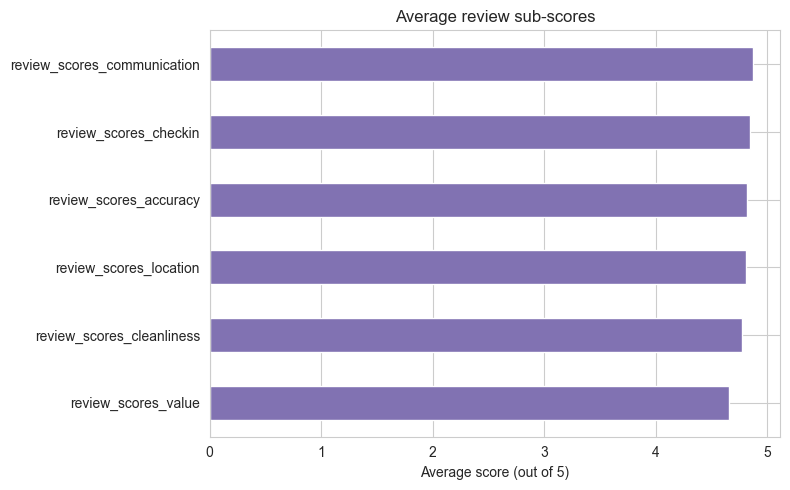

In [12]:
sub_dims = [
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
]

fig, ax = plt.subplots(figsize=(8, 5))
df[sub_dims].mean().sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Average review sub-scores")
ax.set_xlabel("Average score (out of 5)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig15_review_subdimensions.png", dpi=150)
plt.show() 

**Figure 15: Review sub-dimensions.** All review sub-scores are exceptionally high, with average ratings clustered between roughly 4.7 and 4.9 out of 5. Communication receives the highest average score, closely followed by check-in and accuracy, suggesting that hosts generally perform very well on guest interactions and operational aspects of the stay.

The lowest-scoring dimension is value, although it still averages around 4.7. This is notable because, in a dataset where most listings receive near-perfect ratings, even a small gap can indicate the area where guests are most consistently less satisfied. For hosts, this suggests that perceived value for money is the main opportunity for improvement. Guests appear more willing to overlook minor issues with communication or cleanliness than to feel that a property was overpriced relative to the experience delivered.